# PSM Rescoring with MS²Rescore

Database search engines (MaxQuant, Sage, MSFragger, ...) score peptide-spectrum matches (PSMs)
using mass accuracy and the number of matched fragment ions, but leave substantial
information on the table. **MS²Rescore** recovers that information by adding features derived from
machine learning predictors and then re-ranking PSMs with a semi-supervised classifier.

In this tutorial we rescore a real HeLa LC-MS/MS dataset (MaxQuant search) using three
complementary feature generators:

| Feature generator | Features added | Requires |
|-------------------|---------------|----------|
| `basic` | Charge, m/z error, missed cleavages, peptide length, ... | PSM file only |
| `ms2pip` | Cosine similarity, spectral contrast, Pearson *r* between predicted and observed b/y-ions | PSM file + spectra |
| `deeplc` | Absolute and relative RT prediction error | PSM file only |

Features are combined by **mokapot** (a semi-supervised SVM re-implementation of Percolator)
to produce new PSM scores and FDR estimates.

**Dataset**: a 7-minute HeLa gradient run searched with MaxQuant against a human proteome
FASTA. The PSM file (`msms.txt`) and the corresponding MGF spectra file are publicly
available from the
[psm_utils example data](https://github.com/compomics/psm_utils/tree/main/example_files)
and [Zenodo record 18621806](https://zenodo.org/records/18621806).


In [1]:
# Install dependencies (run once)
# !pip install ms2rescore psm-utils matplotlib tensorflow-cpu


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import gzip
import io
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import requests

from psm_utils.io import read_file

from ms2rescore import rescore
from ms2rescore.config_parser import parse_configurations

logging.basicConfig(level=logging.WARNING)
logging.getLogger("deeplc").setLevel(logging.ERROR)
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("ms2rescore").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")


I0000 00:00:1781190563.609225  117741 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1781190564.400742  117741 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
%matplotlib inline


## 1. Dataset

The search was performed with MaxQuant on a 7-minute HeLa gradient run acquired on an
Orbitrap instrument (HCD fragmentation). The `msms.txt` file contains one row per PSM with
the Andromeda score, peptide sequence (in MaxQuant modified-sequence notation), charge,
retention time, and a target/decoy label (`Reverse` column).

| File | Source | Size |
|------|--------|------|
| `msms.txt` | psm_utils example data (GitHub) | ~20 MB |
| `*.mgf` | Zenodo 18621806 | ~91 MB |

> **Note**: downloading the spectra file (~91 MB) may take a minute or two depending on
> your connection speed. The files are cached in `data/` after the first download.


In [4]:
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

MSMS_URL = (
    "https://raw.githubusercontent.com/compomics/psm_utils/main"
    "/example_files/msms.txt.gz"
)
MGF_URL = (
    "https://zenodo.org/api/records/18621806/files"
    "/20161213_NGHF_DBJ_SA_Exp3A_HeLa_1ug_7min_15000_02.mgf/content"
)

msms_path = data_dir / "msms.txt"
mgf_path = data_dir / "20161213_NGHF_DBJ_SA_Exp3A_HeLa_1ug_7min_15000_02.mgf"

if not msms_path.exists():
    print("Downloading msms.txt (~20 MB)...")
    r = requests.get(MSMS_URL, timeout=120)
    with gzip.open(io.BytesIO(r.content)) as f:
        msms_path.write_bytes(f.read())
    print(f"Saved: {msms_path} ({msms_path.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Using cached: {msms_path}")

if not mgf_path.exists():
    print("Downloading spectra (~91 MB)...")
    r = requests.get(MGF_URL, timeout=300, stream=True)
    total = int(r.headers.get("content-length", 0))
    downloaded = 0
    with open(mgf_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            f.write(chunk)
            downloaded += len(chunk)
            if total:
                print(f"  {downloaded / 1e6:.0f} / {total / 1e6:.0f} MB", end="\r")
    print(f"\nSaved: {mgf_path} ({mgf_path.stat().st_size / 1e6:.1f} MB)")
else:
    print(f"Using cached: {mgf_path}")


Using cached: data/msms.txt
Using cached: data/20161213_NGHF_DBJ_SA_Exp3A_HeLa_1ug_7min_15000_02.mgf


## 2. Inspecting the Search Results

Before rescoring, we load the `msms.txt` with psm_utils and examine the Andromeda score
distribution. Good PSM scoring relies on clear separation between:

- **Target PSMs** (sequences from the correct proteome FASTA)
- **Decoy PSMs** (reversed sequences, used to estimate FDR)

The overlap between the two distributions determines how many PSMs can be identified at
a given FDR threshold. MS²Rescore aims to push the two distributions further apart by
adding orthogonal features.


In [5]:
psm_list = read_file(str(msms_path), filetype="msms")
psm_list.calculate_qvalues(lower_score_is_better=False)

df_before = psm_list.to_dataframe()
print(f"Total PSMs: {len(df_before):,}")
print(f"  Targets:  {(~df_before['is_decoy']).sum():,}")
print(f"  Decoys:   {df_before['is_decoy'].sum():,}")

targets_1pct_before = (~df_before['is_decoy'] & (df_before['qvalue'] <= 0.01)).sum()
print(f"\nTargets at 1 % FDR (Andromeda score): {targets_1pct_before:,}")


Total PSMs: 35,556
  Targets:  22,190
  Decoys:   13,366

Targets at 1 % FDR (Andromeda score): 5,480


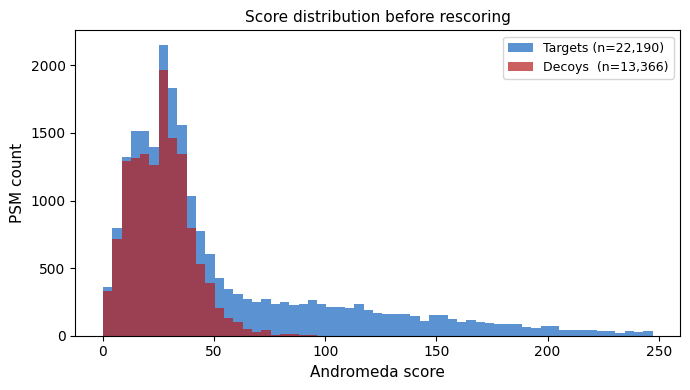

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

targets = df_before[~df_before['is_decoy']]['score']
decoys  = df_before[ df_before['is_decoy']]['score']

bins = np.linspace(0, df_before['score'].quantile(0.99), 60)
ax.hist(targets, bins=bins, alpha=0.7, color='#1565C0', label=f'Targets (n={len(targets):,})')
ax.hist(decoys,  bins=bins, alpha=0.7, color='#B71C1C', label=f'Decoys  (n={len(decoys):,})')

ax.set_xlabel('Andromeda score', fontsize=11)
ax.set_ylabel('PSM count', fontsize=11)
ax.set_title('Score distribution before rescoring', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 3. Running MS²Rescore

### Configuration

MS²Rescore is configured through a nested dictionary that mirrors its JSON/TOML config
file format. Key parameters:

- **`psm_file`** / **`psm_file_type`**: path to the MaxQuant `msms.txt` and its format.
- **`spectrum_path`**: path to the MGF file. Required by the `ms2pip` feature generator
  to match observed spectra with predictions.
- **`spectrum_id_pattern`**: a regex with one capture group that extracts the spectrum
  identifier from the MGF TITLE line. Here the title ends with `scan=4703`, so
  `.*scan=(\d+)$` extracts `4703`, which matches the MaxQuant `Scan number` column.
- **`modification_mapping`**: maps MaxQuant short modification codes (`ac`, `ox`, `de`,
  `gl`) to the PSI-MOD names expected by MS2PIP and DeepLC.
- **`fixed_modifications`**: modifications that are fixed for all peptides
  (carbamidomethylation of Cys is standard in this experiment).
- **`feature_generators`**: which feature sets to compute. Disabling `ms2pip` would
  skip the spectrum matching step and produce faster but less powerful rescoring.
- **`rescoring_engine`**: `mokapot` (semi-supervised SVM, in-process) or `percolator`
  (if installed separately as a binary).


In [7]:
output_dir = data_dir / "output"
output_dir.mkdir(exist_ok=True)

config = parse_configurations(
    {
        "ms2rescore": {
            "psm_file": str(msms_path),
            "psm_file_type": "msms",
            "spectrum_path": str(mgf_path),
            "output_path": str(output_dir / "ms2rescore"),
            "spectrum_id_pattern": r".*scan=(\d+)$",
            "modification_mapping": {
                "gl": "Gln->pyro-Glu",
                "ox": "Oxidation",
                "ac": "Acetylation",
                "de": "Deamidation",
            },
            "fixed_modifications": {"Carbamidomethyl": ["C"]},
            "feature_generators": {
                "basic":  {},
                "ms2pip": {"model": "HCD2021", "ms2_tolerance": 0.02},
                "deeplc": {"calibration_set_size": 0.15},
            },
            "rescoring_engine": {"mokapot": {"train_fdr": 0.05}},
            "log_level": "warning",
            "write_report": False,
        }
    }
)

print("Running MS\u00b2Rescore...")
print("(feature generation + mokapot training typically takes 10\u201315 minutes)")
rescore(config)
print("Done.")


Running MS²Rescore...
(feature generation + mokapot training typically takes 10–15 minutes)


Done.


## 4. Results

The output file `ms2rescore.psms.tsv` contains one row per PSM with:

- **`score`**: the mokapot discriminant score (higher = more likely correct)
- **`qvalue`**: the PSM-level FDR estimate from mokapot
- **`pep`**: posterior error probability
- **`provenance:before_rescoring_score`**: the original Andromeda score
- **`rescoring:*`**: all features that were passed to mokapot

We compare target PSMs identified at 1 % FDR before and after rescoring, and plot the
FDR curves to show the improvement across all FDR thresholds.


In [8]:
output_tsv = output_dir / "ms2rescore.psms.tsv"
df_after = pd.read_csv(output_tsv, sep="	")

# Before: compute q-values from the Andromeda score stored in provenance column
def compute_qvalues(df, score_col, descending=True):
    """Target-decoy q-value computation (BH-monotone)."""
    df = df.sort_values(score_col, ascending=not descending).copy()
    cum_decoy   = df['is_decoy'].cumsum()
    cum_target  = (~df['is_decoy']).cumsum().clip(lower=1)
    raw_fdr     = (cum_decoy / cum_target).clip(upper=1.0).values
    df['_qval'] = np.minimum.accumulate(raw_fdr[::-1])[::-1]
    return df

df_before_scored = compute_qvalues(
    df_after, 'provenance:before_rescoring_score', descending=True
)

n_before = (~df_before_scored['is_decoy'] & (df_before_scored['_qval'] <= 0.01)).sum()
n_after  = (~df_after['is_decoy'] & (df_after['qvalue'] <= 0.01)).sum()

print(f"Targets at 1 % FDR")
print(f"  Before rescoring (Andromeda):  {n_before:,}")
print(f"  After  rescoring (mokapot):    {n_after:,}")
print(f"  Gain:  +{n_after - n_before:,}  (+{100*(n_after - n_before)/n_before:.1f} %)")


Targets at 1 % FDR
  Before rescoring (Andromeda):  6,082
  After  rescoring (mokapot):    7,112
  Gain:  +1,030  (+16.9 %)


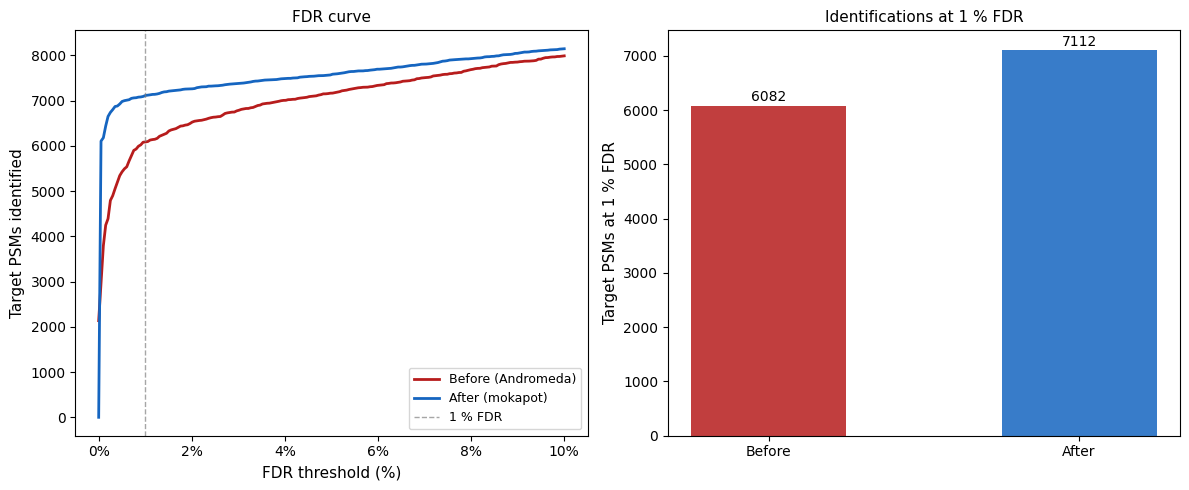

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: FDR curves ---
ax = axes[0]
fdr_thresholds = np.linspace(0, 0.1, 200)

for label, df_scored, score_col, qval_col, color in [
    ('Before (Andromeda)', df_before_scored, 'provenance:before_rescoring_score', '_qval', '#B71C1C'),
    ('After (mokapot)',    df_after,          'score',                             'qvalue', '#1565C0'),
]:
    tgt = df_scored[~df_scored['is_decoy']]
    counts = [(tgt[qval_col] <= t).sum() for t in fdr_thresholds]
    ax.plot(fdr_thresholds * 100, counts, label=label, color=color, linewidth=2)

ax.axvline(1, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='1 % FDR')
ax.set_xlabel('FDR threshold (%)', fontsize=11)
ax.set_ylabel('Target PSMs identified', fontsize=11)
ax.set_title('FDR curve', fontsize=11)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# --- Right: bar chart ---
ax2 = axes[1]
ax2.bar(['Before', 'After'], [n_before, n_after],
        color=['#B71C1C', '#1565C0'], alpha=0.85, width=0.5)
ax2.set_ylabel('Target PSMs at 1 % FDR', fontsize=11)
ax2.set_title('Identifications at 1 % FDR', fontsize=11)
for i, v in enumerate([n_before, n_after]):
    ax2.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


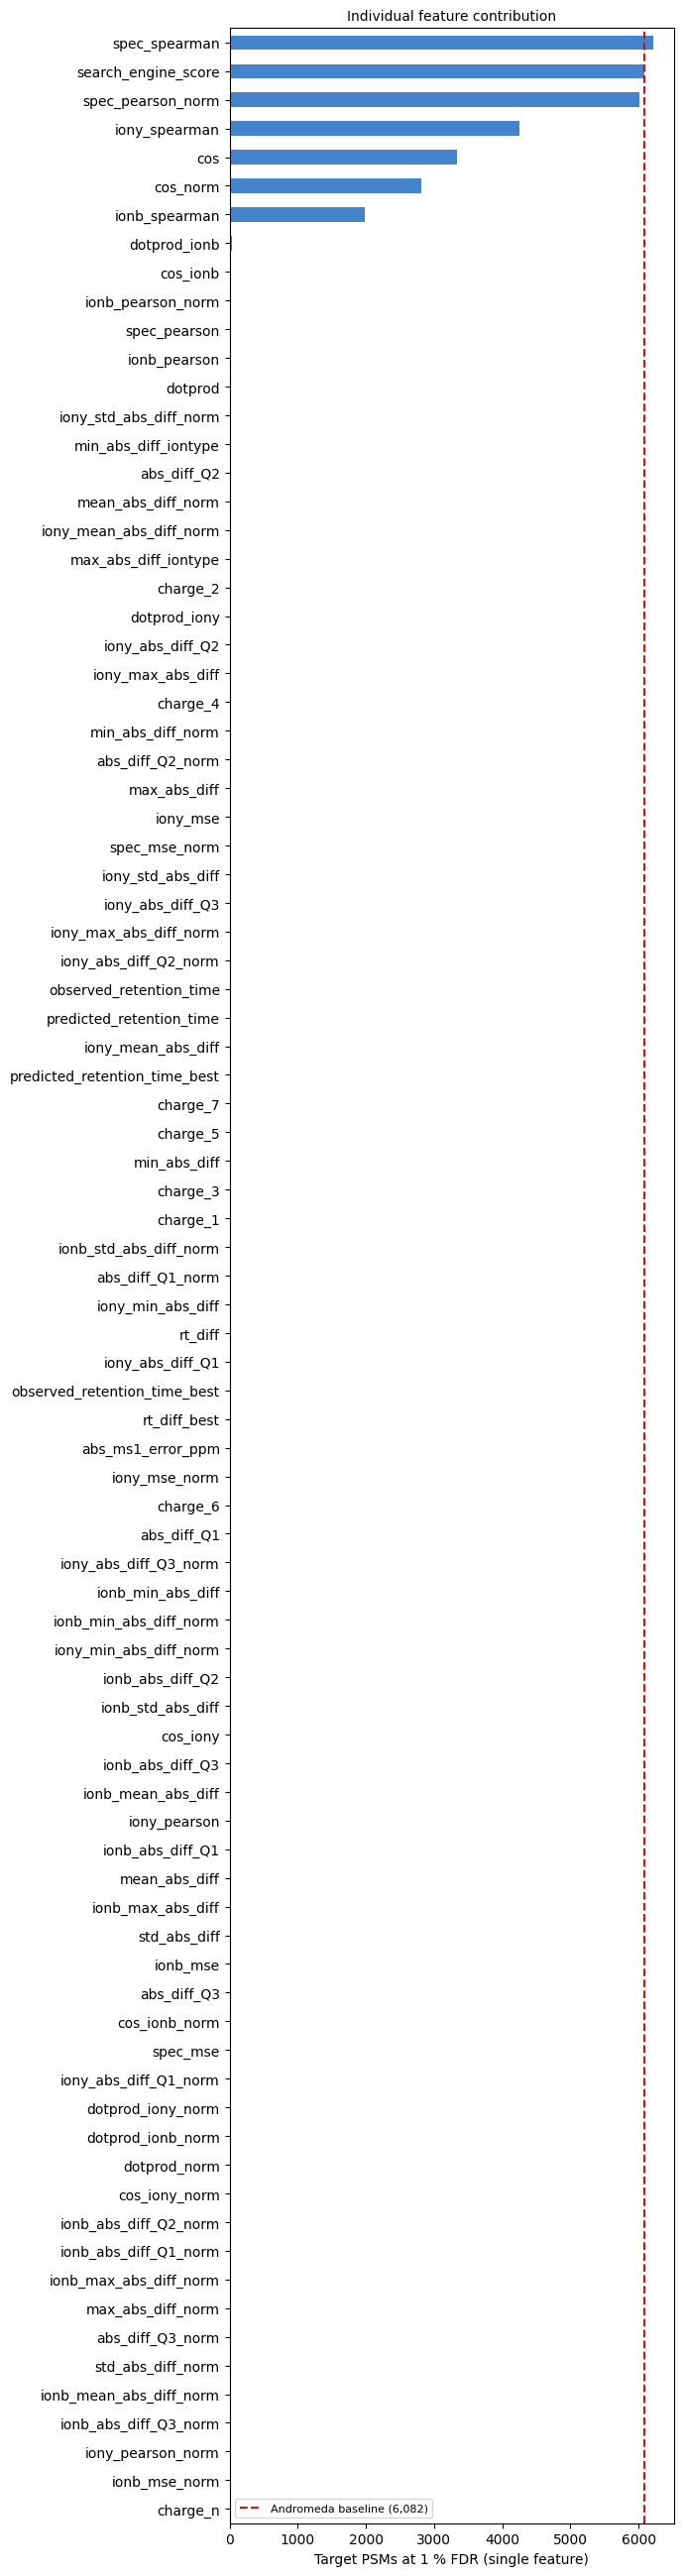

In [10]:
# Feature contribution: compare individual feature q-values at 1% FDR
rescoring_cols = [c for c in df_after.columns if c.startswith('rescoring:')]
feature_gains = {}
for col in rescoring_cols:
    df_feat = compute_qvalues(df_after.dropna(subset=[col]), col, descending=True)
    n_feat = (~df_feat['is_decoy'] & (df_feat['_qval'] <= 0.01)).sum()
    feature_gains[col.replace('rescoring:', '')] = n_feat

feat_df = pd.Series(feature_gains).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(4, len(feat_df) * 0.3)))
feat_df.plot.barh(ax=ax, color='#1565C0', alpha=0.8)
ax.axvline(n_before, color='#B71C1C', linestyle='--', linewidth=1.5,
           label=f'Andromeda baseline ({n_before:,})')
ax.set_xlabel('Target PSMs at 1 % FDR (single feature)', fontsize=10)
ax.set_title('Individual feature contribution', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

MS²Rescore improved peptide identifications at 1 % FDR by combining three complementary
feature generators:

- **`basic`**: simple features derived directly from the search result (charge, m/z error,
  missed cleavages, etc.) that the search engine itself does not optimally use.
- **`ms2pip`**: fragment ion features quantifying how well the predicted HCD spectrum
  matches the observed spectrum (cosine similarity, spectral contrast angle, Pearson *r*).
  These features exploit MS2PIP's knowledge of fragmentation chemistry.
- **`deeplc`**: retention time deviation features comparing the DeepLC-predicted RT with
  the observed RT. Correct identifications cluster around zero RT deviation; incorrect
  ones are spread.

All features are passed to **mokapot**, a semi-supervised SVM that learns a linear
combination of features to maximally separate targets from decoys.

### Further reading

- [MS²Rescore documentation](https://ms2rescore.readthedocs.io)
- Declercq *et al.*, *Journal of Proteome Research* (2023).
  [doi:10.1021/acs.jproteome.3c00785](https://doi.org/10.1021/acs.jproteome.3c00785)
- [mokapot](https://mokapot.readthedocs.io) — the rescoring engine used here.
